In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString
import folium
from folium.plugins import Draw
from IPython.display import display, HTML, IFrame
import ast

In [2]:
from IPython.core.display import display, HTML

display(HTML("""
<style>
.jp-OutputArea-output {
    overflow-y: auto;
}
</style>
"""))


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_26052\3993278352.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [3]:
# Load the dataset
file_path = r'C:\Users\Prakhar.Sarkar\OneDrive - SRP Management Services\Documents\_For_Prakhar\Sample data from Vesna vLandedWells.xlsx'  
df = pd.read_excel(file_path)

In [4]:
def robust_parse(x):
    if pd.isna(x):
        return [None] * 7  # Handle NaNs by returning a list of Nones
    try:
        if isinstance(x, str):
            return ast.literal_eval(x)  # Attempt to parse string as a Python literal
        else:
            return [x] + [None] * 6  # If x is not a string, return it as the first element with None padding
    except Exception as e:
        #print(f"Failed to parse: {x} with error {e}")  # Optionally log the error for debugging
        return [None] * 7  # Return None values if parsing fails

In [5]:
# Columns to be parsed
param_columns = [
    'Oil_Params_P20', 'Gas_Params_P20', 'Oil_Params_P35', 'Gas_Params_P35', 
    'Oil_Params_P50', 'Gas_Params_P50', 'Oil_Params_P65', 'Gas_Params_P65', 
    'Oil_Params_P80', 'Gas_Params_P80', 'Water_Params_P50'
]
# Apply robust parsing to each column
for col in param_columns:
    df[col] = df[col].apply(robust_parse)
# Split each parameter into its own column
new_columns = []
for col in param_columns:
    expanded_cols = [f'{col}_Method', f'{col}_BuildupRate', f'{col}_MonthsInProd', 
                     f'{col}_InitialProd', f'{col}_DiCoefficient', f'{col}_BCoefficient', 
                     f'{col}_MinDeclineRate']
    temp_df = pd.DataFrame(df[col].tolist(), columns=expanded_cols)
    # Convert numeric columns to float
    for num_col in expanded_cols:
        if num_col.endswith('_Method'):
            temp_df[num_col] = temp_df[num_col].astype(str)  # Ensuring 'Method' is of string type
        else:
            temp_df[num_col] = pd.to_numeric(temp_df[num_col], errors='coerce')  # Convert to numeric and handle errors
    df = pd.concat([df, temp_df], axis=1)

# Drop the original parameter columns
df.drop(columns=param_columns, inplace=True)

In [6]:
# Handling NaN values differently for categorical and numerical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
for column in df.columns:
    if column in categorical_columns:
        df[column] = df[column].fillna('Unknown')  # Using 'Unknown' for categorical data
    else:
        df[column] = df[column].fillna(0)  # Assuming 0 is a reasonable fill for numerical data
# Drop rows where any of the new parameter columns have missing data
df.dropna(subset=[col for col in df.columns if 'Params' in col], inplace=True)

In [7]:
# Drop rows where 'FluidPerFoot_bblft' or 'ProppantPerFoot' are zero
df = df[(df['FluidPerFoot_bblft'] != 0) & (df['ProppantPerFoot'] != 0)]
df = df[(df['EUR_30yr_Actual_Gas_P50_MMCF'] != 0) & (df['EUR_30yr_Actual_Oil_P50_MBO'] != 0) & (df['EUR_30yr_Actual_Water_P50_MBBL'] != 0)]
df = df[(df['HEELPOINT_LAT'] != 0)]

In [8]:
# Define a function to replace zeros with the P50 value for the same category
def replace_zeros_with_P50(df):
    # Replace for EUR values
    phases = ['Oil', 'Gas', 'Water']  # Assuming Water is also needed; adjust as necessary
    years = ['30yr']  # Adjust or extend if there are other year ranges
    
    for phase in phases:
        for year in years:
            p50_col = f'EUR_{year}_Actual_{phase}_P50_' + ('MBO' if phase != 'Gas' else 'MMCF')
            if phase == 'Water':
                p50_col = f'EUR_{year}_Actual_{phase}_P50_MBBL'  # Assuming water is measured in MBBL

            for p in ['P20', 'P35', 'P65', 'P80']:
                p_col = f'EUR_{year}_Actual_{phase}_{p}_' + ('MBO' if phase != 'Gas' else 'MMCF')
                if phase == 'Water':
                    p_col = f'EUR_{year}_Actual_{phase}_{p}_MBBL'
                
                if p_col in df.columns and p50_col in df.columns:
                    df.loc[df[p_col] == 0, p_col] = df[p50_col]

    # Replace for parameters
    params = ['Method', 'BuildupRate', 'MonthsInProd', 'InitialProd', 'DiCoefficient', 'BCoefficient', 'MinDeclineRate']
    terminal decline
    for phase in ['Oil', 'Gas', 'Water']:  # Assuming Water parameters are also needed
        for param in params:
            p50_col = f'{phase}_Params_P50_{param}'
            for p in ['P20', 'P35', 'P65', 'P80']:
                p_col = f'{phase}_Params_{p}_{param}'
                if p_col in df.columns and p50_col in df.columns:
                    df.loc[df[p_col] == 0, p_col] = df[p50_col]

In [9]:
replace_zeros_with_P50(df)

In [10]:
# # Drop rows where latitude or longitude values are missing
# df.dropna(subset=['HEELPOINT_LAT', 'HEELPOINT_LON', 'MIDPOINT_LAT', 'MIDPOINT_LON', 'TOEPOINT_LAT', 'TOEPOINT_LON'], inplace=True)

# # Create a GeoDataFrame
# gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['HEELPOINT_LON'], df['HEELPOINT_LAT']))

# # Create a LineString for each well
# gdf['line'] = gdf.apply(lambda row: LineString([
#     (row['HEELPOINT_LON'], row['HEELPOINT_LAT']),
#     (row['MIDPOINT_LON'], row['MIDPOINT_LAT']),
#     (row['TOEPOINT_LON'], row['TOEPOINT_LAT'])
# ]), axis=1)

# # Create a GeoDataFrame with the LineStrings
# line_gdf = gpd.GeoDataFrame(gdf, geometry='line')

# # Calculate bounds to set the map's initial view
# bounds = line_gdf.total_bounds  # [minx, miny, maxx, maxy]
# center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]  # [(miny + maxy)/2, (minx + maxx)/2]

# # Create a folium map centered on the calculated center
# m = folium.Map(location=center, zoom_start=10)

# # Fit map to bounds
# m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])


# # Add the lines to the map
# for _, row in line_gdf.iterrows():
#     line_points = [
#         (row['HEELPOINT_LAT'], row['HEELPOINT_LON']),
#         (row['MIDPOINT_LAT'], row['MIDPOINT_LON']),
#         (row['TOEPOINT_LAT'], row['TOEPOINT_LON'])
#     ]
#     folium.PolyLine(line_points, color='blue').add_to(m)
#     # Add marker for midpoint with a popup showing coordinates or other info
#     folium.Marker(location=line_points[1], popup=f'Well ID: {row["WellName"]}', tooltip='Click for info').add_to(m)

# # Add draw control to the map to allow for area selection
# draw = Draw(export=True)
# m.add_child(draw)

# # Display the map in the Jupyter notebook
# m.save('wells_map.html')
# display(IFrame('wells_map.html', width=700, height=500))


In [11]:
def add_neighbor_eur(df):
    if df is None:
        raise ValueError("The input DataFrame is None. Please provide a valid DataFrame.")

    # Check if the UWI column exists
    if 'UWI' not in df.columns:
        raise ValueError("The input DataFrame does not contain the 'UWI' column.")

    # Define the EUR columns we're interested in
    eur_oil_columns = ['EUR_30yr_Actual_Oil_P20_MBO', 'EUR_30yr_Actual_Oil_P35_MBO', 
                       'EUR_30yr_Actual_Oil_P50_MBO', 'EUR_30yr_Actual_Oil_P65_MBO', 
                       'EUR_30yr_Actual_Oil_P80_MBO']
    eur_gas_columns = ['EUR_30yr_Actual_Gas_P20_MMCF', 'EUR_30yr_Actual_Gas_P35_MMCF', 
                       'EUR_30yr_Actual_Gas_P50_MMCF', 'EUR_30yr_Actual_Gas_P65_MMCF', 
                       'EUR_30yr_Actual_Gas_P80_MMCF']

    # Check if the required EUR columns exist
    missing_columns = [col for col in eur_oil_columns + eur_gas_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"The input DataFrame is missing the following required columns: {missing_columns}")

    # Create a mapping DataFrame that will be used for mapping EUR values
    eur_map = df.set_index('UWI')[eur_oil_columns + eur_gas_columns].fillna(0).copy()

    # Iterate over NNAZ and NNSZ columns
    for prefix in ['NNAZ', 'NNSZ']:
        num_cols = 6 if prefix == 'NNAZ' else 2  # Assuming 6 NNAZ and 2 NNSZ columns
        for i in range(1, num_cols + 1):
            uwi_col = f'{prefix}_{i}_UWI'
            if uwi_col in df.columns:  # Ensure the UWI column exists
                for eur_col in eur_oil_columns + eur_gas_columns:
                    new_col_name = f'{prefix}_{i}_{eur_col}'
                    # Use the map function to add EUR values from the eur_map DataFrame
                    df[new_col_name] = df[uwi_col].map(eur_map[eur_col])

    return df

In [12]:
df = add_neighbor_eur(df)

In [13]:
columns_to_drop=['UWI10', 'CompletionDate' ,'UWI', 'WellName','NNAZ_1_UWI','NNAZ_2_UWI','NNAZ_3_UWI','NNAZ_4_UWI','NNAZ_5_UWI','NNAZ_6_UWI','NNSZ_1_UWI',
                'NNSZ_2_UWI','LeaseName', 'WellNumber', 'CurrentOperatorName', 'OriginalOperatorName', 'DrillingContractorName', 'PermitDate', 'SpudDate','FORMATION_CONDENSE', 'Unique_PDP_ID','EUR_30yr_Actual_Oil_P20_MBO',
 'EUR_30yr_Actual_Gas_P20_MMCF', 'EUR_30yr_Actual_Oil_P35_MBO', 'EUR_30yr_Actual_Gas_P35_MMCF', 'EUR_30yr_Actual_Oil_P50_MBO', 'EUR_30yr_Actual_Gas_P50_MMCF',
 'EUR_30yr_Actual_Oil_P65_MBO', 'EUR_30yr_Actual_Gas_P65_MMCF', 'EUR_30yr_Actual_Oil_P80_MBO', 'EUR_30yr_Actual_Gas_P80_MMCF', 'EUR_30yr_Actual_Water_P50_MBBL','WELL_TORTUOSITY','DEPTH_TO_TOP_2Q',
 'DEPTH_TO_TOP_3Q', 'DEPTH_TO_TOP_4Q', 'AZIMUTH','DEPTH_ABOVE_ZONE_2Q',  'DEPTH_ABOVE_ZONE_3Q', 'DEPTH_ABOVE_ZONE_4Q',
]
# Dropping the columns
df.drop(columns=columns_to_drop, inplace=True)
months_in_prod_columns = [col for col in df.columns if '_MonthsInProd' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if '_Method' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if '_MinDeclineRate' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if '_MinDeclineRate' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)

In [14]:
non_null_counts = df.count()

# Display columns with discrepancies in their count of non-null values
# This assumes the DataFrame has rows where some columns may be consistently non-null
max_count = non_null_counts.max()
discrepancy_columns = non_null_counts[non_null_counts < max_count]
discrepancy_columns

NNAZ_1_EUR_30yr_Actual_Oil_P20_MBO     818
NNAZ_1_EUR_30yr_Actual_Oil_P35_MBO     818
NNAZ_1_EUR_30yr_Actual_Oil_P50_MBO     818
NNAZ_1_EUR_30yr_Actual_Oil_P65_MBO     818
NNAZ_1_EUR_30yr_Actual_Oil_P80_MBO     818
                                      ... 
NNSZ_2_EUR_30yr_Actual_Gas_P20_MMCF    703
NNSZ_2_EUR_30yr_Actual_Gas_P35_MMCF    703
NNSZ_2_EUR_30yr_Actual_Gas_P50_MMCF    703
NNSZ_2_EUR_30yr_Actual_Gas_P65_MMCF    703
NNSZ_2_EUR_30yr_Actual_Gas_P80_MMCF    703
Length: 80, dtype: int64

In [41]:
list(y_headers)

['Oil_Params_P20_BuildupRate',
 'Oil_Params_P20_InitialProd',
 'Oil_Params_P20_DiCoefficient',
 'Oil_Params_P20_BCoefficient',
 'Gas_Params_P20_BuildupRate',
 'Gas_Params_P20_InitialProd',
 'Gas_Params_P20_DiCoefficient',
 'Gas_Params_P20_BCoefficient',
 'Oil_Params_P35_BuildupRate',
 'Oil_Params_P35_InitialProd',
 'Oil_Params_P35_DiCoefficient',
 'Oil_Params_P35_BCoefficient',
 'Gas_Params_P35_BuildupRate',
 'Gas_Params_P35_InitialProd',
 'Gas_Params_P35_DiCoefficient',
 'Gas_Params_P35_BCoefficient',
 'Oil_Params_P50_BuildupRate',
 'Oil_Params_P50_InitialProd',
 'Oil_Params_P50_DiCoefficient',
 'Oil_Params_P50_BCoefficient',
 'Gas_Params_P50_BuildupRate',
 'Gas_Params_P50_InitialProd',
 'Gas_Params_P50_DiCoefficient',
 'Gas_Params_P50_BCoefficient',
 'Oil_Params_P65_BuildupRate',
 'Oil_Params_P65_InitialProd',
 'Oil_Params_P65_DiCoefficient',
 'Oil_Params_P65_BCoefficient',
 'Gas_Params_P65_BuildupRate',
 'Gas_Params_P65_InitialProd',
 'Gas_Params_P65_DiCoefficient',
 'Gas_Params_P65

In [15]:
# Fill missing values with zero
df = df.fillna(0)

In [16]:
non_null_counts = df.count()

# Display columns with discrepancies in their count of non-null values
# This assumes the DataFrame has rows where some columns may be consistently non-null
max_count = non_null_counts.max()
discrepancy_columns = non_null_counts[non_null_counts < max_count]
discrepancy_columns

Series([], dtype: int64)

In [17]:
# Define bounds for each basin in a dictionary.
# The keys are basin names, and the values are tuples of (lat_min, lat_max, lon_min, lon_max).
basin_bounds = {
    'Midland': {'lat_range': (29, 34), 'lon_range': (-110, -109)}
    # Add more basins with their geographic bounds 
}
def assign_basin_tc(row):
    # Check if BasinTC is 0 or missing (use pd.isna() and explicitly handle pd.NA)
    if pd.isna(row['BasinTC'])== 'Unknown' or row['BasinTC'] == 0:
        matched_basin = None
        for basin, bounds in basin_bounds.items():
            # Ensure all comparisons are done within bounds
            if ((bounds['lat_range'][0] <= row['HEELPOINT_LAT'] <= bounds['lat_range'][1] and
                 bounds['lon_range'][0] <= row['HEELPOINT_LON'] <= bounds['lon_range'][1]) or
                (bounds['lat_range'][0] <= row['MIDPOINT_LAT'] <= bounds['lat_range'][1] and
                 bounds['lon_range'][0] <= row['MIDPOINT_LON'] <= bounds['lon_range'][1]) or
                (bounds['lat_range'][0] <= row['TOEPOINT_LAT'] <= bounds['lat_range'][1] and
                 bounds['lon_range'][0] <= row['TOEPOINT_LON'] <= bounds['lon_range'][1])):
                matched_basin = basin
                break
        return matched_basin if matched_basin else row['BasinTC']
    return row['BasinTC']

In [18]:
# Apply the function to each row
df['BasinTC'] = df.apply(assign_basin_tc, axis=1)
# Drop rows where 'BasinTC' is 'Unknown'
df = df[df['BasinTC'] != 'Unknown']

months_in_prod_columns = [col for col in df.columns if '_LAT' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if '_LON' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
# months_in_prod_columns = [col for col in df.columns if 'COMPLETION_RELATIONSHIP' in col]
# df.drop(months_in_prod_columns, axis=1, inplace=True)
# months_in_prod_columns = [col for col in df.columns if 'WELL_TRAJECTORY' in col]
# df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if 'PRIMARY_FORMATION' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if 'Typecurve' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
df.reset_index(drop=True, inplace=True)
df_orig = df

# Print the shape of the DataFrame to confirm rows have been dropped
print(f"Updated DataFrame shape: {df.shape}")

Updated DataFrame shape: (1015, 174)


In [19]:
# Ensure BasinTC and FORMATION_CONDENSED are categorical
df['BasinTC'] = df['BasinTC'].astype(str)
df['FORMATION_CONDENSED'] = df['FORMATION_CONDENSED'].astype(str)

In [20]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [21]:
# Define categorical and numerical columns excluding 'BasinTC' and 'FORMATION_CONDENSED'
categorical_columns = [col for col in df.select_dtypes(include=['object', 'category']).columns.tolist() if col not in ['BasinTC', 'FORMATION_CONDENSED']]
# Prepare data for modeling
y_headers = [col for col in df.columns if 'Params' in col]             
numerical_columns = [col for col in df.columns if col not in categorical_columns + ['BasinTC', 'FORMATION_CONDENSED', *y_headers]]
# Update feature_columns excluding 'BasinTC' and 'FORMATION_CONDENSED'
feature_columns = numerical_columns + categorical_columns

In [22]:
# # Calculate the number of unique categories and their names for each column
# category_info = {col: {'count': df[col].nunique(), 'names': df[col].unique()} for col in categorical_columns}
# # Print the number of categories grouped by the header name
# for header, info in category_info.items():
#     print(f"{header}:")
#     print(f"  Count of Categories: {info['count']}")
#     print(f"  Categories: {info['names']}\n")
# # Print the shape of the DataFrame to confirm rows have been dropped
# print(f"Updated DataFrame shape: {df.shape}")

In [23]:
# Initialize a dictionary to keep LabelEncoders for each column
encoders = {}
# Encode categorical columns and store the encoders
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # Convert and encode
    encoders[col] = le  # Store the encoder for inverse_transform

In [24]:
# Normalize numerical features
scaler = StandardScaler()
#df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [25]:
# Split data
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42)

In [27]:
# Define function to prepare data
def prepare_data(df, numerical_columns, categorical_columns, scaler):
    df = df.copy()  # Create a copy of the dataframe to avoid SettingWithCopyWarning
    df.loc[:, numerical_columns] = scaler.transform(df[numerical_columns])
    df.loc[:, categorical_columns] = df[categorical_columns].astype(np.int32)
    return df
# Define function to filter data by basin and formation
def filter_by_basin_and_formation(dfinput, basin, formation):
    return dfinput[(dfinput['BasinTC'] == basin) & (dfinput['FORMATION_CONDENSED'] == formation)]
def debug_shapes(train, val, test, y_headers):
    print(f'Train X shape: {train.shape}, Train Y shape: {train[y_headers].shape}')
    print(f'Val X shape: {val.shape}, Val Y shape: {val[y_headers].shape}')
    print(f'Test X shape: {test.shape}, Test Y shape: {test[y_headers].shape}')

In [28]:
# Apply scaling on train, validate and test sets
scaler.fit(train_df[numerical_columns])  # Fit only on training data

StandardScaler()

In [29]:
# Assuming df, train_df, val_df, test_df are defined and contain the necessary columns
unique_combinations = df[['BasinTC', 'FORMATION_CONDENSED']].drop_duplicates()
print(unique_combinations)

     BasinTC FORMATION_CONDENSED
0    Midland                 LSS
1    Midland                 WCA
2    Midland                 WCB
6    Midland                 MSS
17   Midland                 WCD
18   Midland                 JMS
29   Midland                Dean
131  Midland                 WCC


In [30]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate, Embedding, Flatten
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1, l2
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import Callback

In [31]:
class RealTimePlottingCallback(Callback):
    def __init__(self, combo_description):
        super().__init__()
        self.combo_description = combo_description
        self.epochs = []
        self.losses = []
        self.val_losses = []
    def on_epoch_end(self, epoch, logs=None):
        self.epochs.append(epoch)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
    def on_train_end(self, logs=None):
        plt.figure(figsize=(10, 4))
        plt.plot(self.epochs, self.losses, label='Training Loss', color='blue')
        plt.plot(self.epochs, self.val_losses, label='Validation Loss', color='red')
        plt.title(f'Training and Validation Loss for {self.combo_description}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

In [32]:
def build_model(numerical_columns, categorical_columns, df, output_size, embedding_output_dim=20, dense_layer_sizes=[128, 64], dropout_rate=0.3, regularization=None, activation='relu', optimizer='adam', loss_function='mse'):
    numerical_input = Input(shape=(len(numerical_columns),), name='num_input')
    categorical_inputs = [Input(shape=(1,), name=f'cat_input_{i}') for i, _ in enumerate(categorical_columns)]
    embeddings = [Embedding(input_dim=df[col].nunique()+1, output_dim=embedding_output_dim, name=f'emb_{col}')(cat_input)
                  for cat_input, col in zip(categorical_inputs, categorical_columns)]
    flat_embeddings = [Flatten()(emb) for emb in embeddings]
    merged = Concatenate()([numerical_input] + flat_embeddings)
    x = merged
    for size in dense_layer_sizes:
        x = Dense(size, activation=activation, kernel_regularizer=regularization)(x)
        x = Dropout(dropout_rate)(x)
    
    output = Dense(output_size, activation='linear')(x)  # Single output layer for all targets
    model = Model(inputs=[numerical_input] + categorical_inputs, outputs=output)
    
    if optimizer == 'adam':
        opt = Adam(learning_rate=0.001)
    elif optimizer == 'sgd':
        opt = SGD(learning_rate=0.001)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=0.001)
    
    model.compile(optimizer=opt, loss=loss_function)
    return model


Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with config: {'embedding_output_dim': 20, 'dense_layer_sizes': [256, 128], 'dropout_rate': 0.3, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x000001F6AD376090>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}


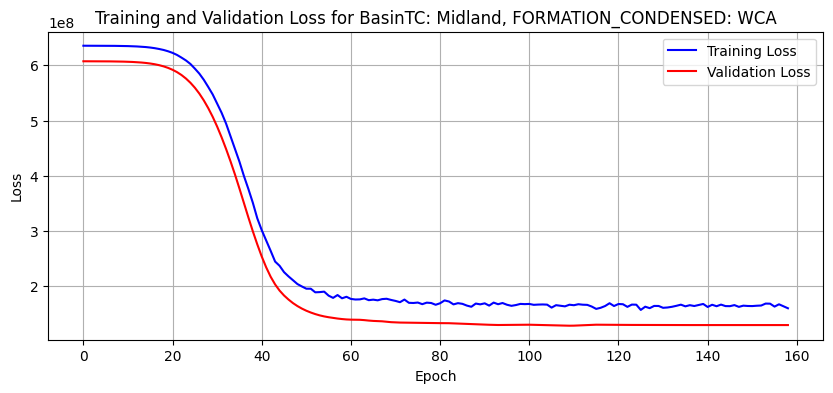

Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with config: {'embedding_output_dim': 20, 'dense_layer_sizes': [256, 128], 'dropout_rate': 0.3, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x000001F6AD376090>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}


In [33]:
# Assuming df, train_df, val_df, test_df are defined and contain the necessary columns
# unique_combinations = df[['BasinTC', 'FORMATION_CONDENSED']].drop_duplicates()
configurations = [
    {'embedding_output_dim': 20, 'dense_layer_sizes': [256, 128], 'dropout_rate': 0.3, 'regularization': l2(0.01), 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'},
   # {'embedding_output_dim': 30, 'dense_layer_sizes': [256, 128], 'dropout_rate': 0.4, 'regularization': l2(0.01), 'activation': 'relu', 'optimizer': 'sgd', 'loss_function': 'mae'},
   # {'embedding_output_dim': 15, 'dense_layer_sizes': [64, 32], 'dropout_rate': 0.2, 'regularization': l1(0.01), 'activation': 'relu', 'optimizer': 'rmsprop', 'loss_function': 'mse'}
]
# Assuming df, train_df, val_df, test_df are defined and contain the necessary columns
specific_combinations = df[
    (df['BasinTC'] == 'Midland') & 
    #(df['FORMATION_CONDENSED'].isin(['LSS', 'WCA', 'WCB', 'WCD']))
    (df['FORMATION_CONDENSED'].isin(['WCA']))
].drop_duplicates(subset=['BasinTC', 'FORMATION_CONDENSED'])
models = {}

for index, row in specific_combinations.iterrows():
    basin = row['BasinTC']
    formation = row['FORMATION_CONDENSED']
    combo_description = f'BasinTC: {basin}, FORMATION_CONDENSED: {formation}'    
    combo_train = filter_by_basin_and_formation(train_df, basin, formation)
    combo_val = filter_by_basin_and_formation(val_df, basin, formation)
    combo_test = filter_by_basin_and_formation(test_df, basin, formation)
    
    #debug_shapes(combo_train, combo_val, combo_test, y_headers)
    
    combo_train = prepare_data(combo_train, numerical_columns, categorical_columns, scaler)
    combo_val = prepare_data(combo_val, numerical_columns, categorical_columns, scaler)
    combo_test = prepare_data(combo_test, numerical_columns, categorical_columns, scaler)
    
    #debug_shapes(combo_train, combo_val, combo_test, y_headers)
    
    output_size = len(train_df[y_headers].columns)
    
    for config in configurations:
        print(f"Starting training for combination: {combo_description} with config: {config}")
        model = build_model(numerical_columns, categorical_columns, df, output_size, **config)
        
        real_time_plotter = RealTimePlottingCallback(combo_description=combo_description)
        model.fit(
            x=[combo_train[numerical_columns].values] + [combo_train[col].astype(int).values.reshape(-1, 1) for col in categorical_columns], 
            y=combo_train[y_headers].values,  # Use entire y_headers as output
            validation_data=(
                [combo_val[numerical_columns].values] + [combo_val[col].astype(int).values.reshape(-1, 1) for col in categorical_columns],
                combo_val[y_headers].values  # Use entire y_headers as output
            ),
            epochs=1000, 
            batch_size=100, 
            callbacks=[
                real_time_plotter, 
                EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True), 
                ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=10)
            ],
            verbose=0
        )      
        models[(basin, formation, str(config))] = model
        print(f"Training completed for combination: {combo_description} with config: {config}")


In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [35]:
# Function to denormalize numerical data
def denormalize_data(data, scaler):
    return scaler.inverse_transform(data)
# Function to decode categorical data
def decode_categorical(data, encoders, column_names):
    decoded_data = {}
    for i, col in enumerate(column_names):
        le = encoders[col]
        decoded_data[col] = le.inverse_transform(data[:, i].astype(int))
    return decoded_data

In [40]:
# Evaluate the models
evaluation_results = {}
for (basin, formation, config_str), model in models.items():
    # Filter the test data for the specific basin and formation
    combo_test = filter_by_basin_and_formation(test_df, basin, formation)
    # Extract numerical and categorical data from the filtered test set
    numerical_data = combo_test[numerical_columns].values
    categorical_data = [combo_test[col].astype(int).values.reshape(-1, 1) for col in categorical_columns]
    # Prepare the target values (y_true)
    y_true = combo_test[y_headers].values  # Use entire y_headers as output

    # Predict outputs using the model
    #print(f"Shapes before prediction: Numerical Data {numerical_data.shape}, Categorical Data {[c.shape for c in categorical_data]}")
    y_pred = model.predict([numerical_data] + categorical_data)
    #print(f"Predicted output shape: {y_pred.shape}")  # Debug the shape of predicted outputs

    # Calculating evaluation metrics
    if y_true.shape == y_pred.shape:
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        evaluation_results[(basin, formation, config_str)] = {'MSE': mse, 'MAE': mae}
        print(f"Performance for Basin: {basin}, Formation: {formation}, Config: {config_str} - MSE: {mse:.4f}, MAE: {mae:.4f}")
    else:
        print(f"Shape mismatch between y_true {y_true.shape} and y_pred {y_pred.shape}, check data preparation steps.")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Performance for Basin: Midland, Formation: WCA, Config: {'embedding_output_dim': 20, 'dense_layer_sizes': [256, 128], 'dropout_rate': 0.3, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x000001F6AD376090>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'} - MSE: 21036309254482.8828, MAE: 2952090.9384


In [37]:
# Define function to plot hyperbolic decline curve
def plot_hyperbolic_curve(time, actual, predicted, title):
    plt.figure(figsize=(10, 6))
    plt.plot(time, actual, label='Actual', marker='o')
    plt.plot(time, predicted, label='Predicted', marker='x')
    plt.title(title)
    plt.xlabel('Time (Years)')
    plt.ylabel('Production Rate')
    plt.legend()
    plt.show()

# Define function to evaluate and plot specific combination
def evaluate_and_plot_hyperbolic_curve(basin, formation, model, numerical_columns, categorical_columns, y_headers):
    combo_test = filter_by_basin_and_formation(test_df, basin, formation)
    numerical_data = combo_test[numerical_columns].values
    categorical_data = [combo_test[col].astype(int).values.reshape(-1, 1) for col in categorical_columns]
    y_true = combo_test[y_headers].values

    # Make predictions
    y_pred = model.predict([numerical_data] + categorical_data)

    # Ensure the predicted shape matches the true values
    if y_true.shape == y_pred.shape:
        for param in ['Oil_Params_P50_BuildupRate', 'Oil_Params_P50_InitialProd', 'Oil_Params_P50_DiCoefficient', 'Oil_Params_P50_BCoefficient']:
            actual = y_true[:, y_headers.index(param)]
            predicted = y_pred[:, y_headers.index(param)]
            print(f'{param} - Actual range: {actual.min()} to {actual.max()}, Predicted range: {predicted.min()} to {predicted.max()}')
            
            # Assume time range for 30 years
            time = np.arange(0, 30, 1)  # 30 years
            q_i = actual[0]  # Initial production rate
            b = predicted[0]  # Buildup rate coefficient
            D_i = predicted[1]  # Decline rate coefficient
            q_t = q_i / (1 + b * D_i * time) ** (1 / b)
            
            plot_hyperbolic_curve(time, actual[:len(time)], q_t, f'{param} - {basin}, {formation}')
    else:
        print(f"Shape mismatch between y_true {y_true.shape} and y_pred {y_pred.shape}")



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Performance for Basin: Midland, Formation: WCA, Config: {'embedding_output_dim': 20, 'dense_layer_sizes': [256, 128], 'dropout_rate': 0.3, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x000001F6AD376090>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'} - MSE: 21036309254482.8828, MAE: 2952090.9384
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Oil_Params_P50_BuildupRate - Actual range: -19559.0 to 37139.0, Predicted range: 1847103.75 to 5320767.0


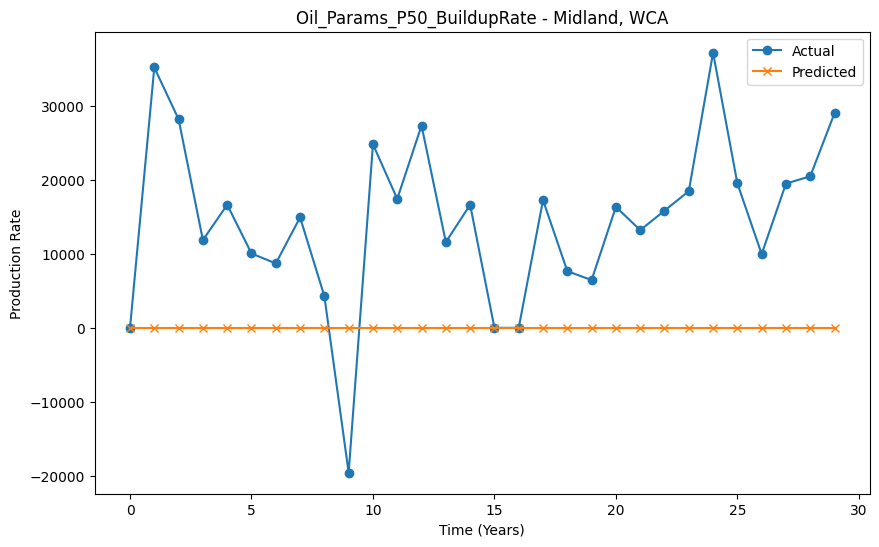

Oil_Params_P50_InitialProd - Actual range: 15674.0 to 69606.0, Predicted range: 4776102.5 to 13746672.0


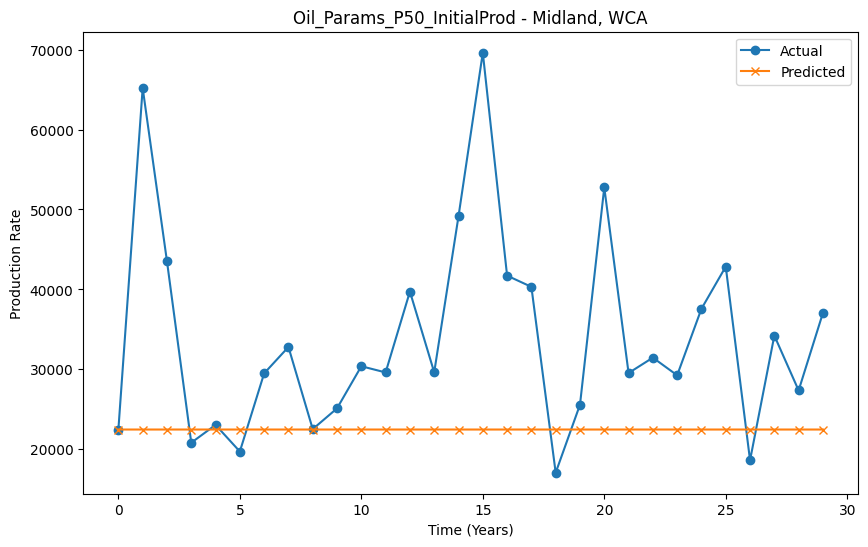

Oil_Params_P50_DiCoefficient - Actual range: 51.4 to 92.08, Predicted range: 29414.064453125 to 82754.5234375


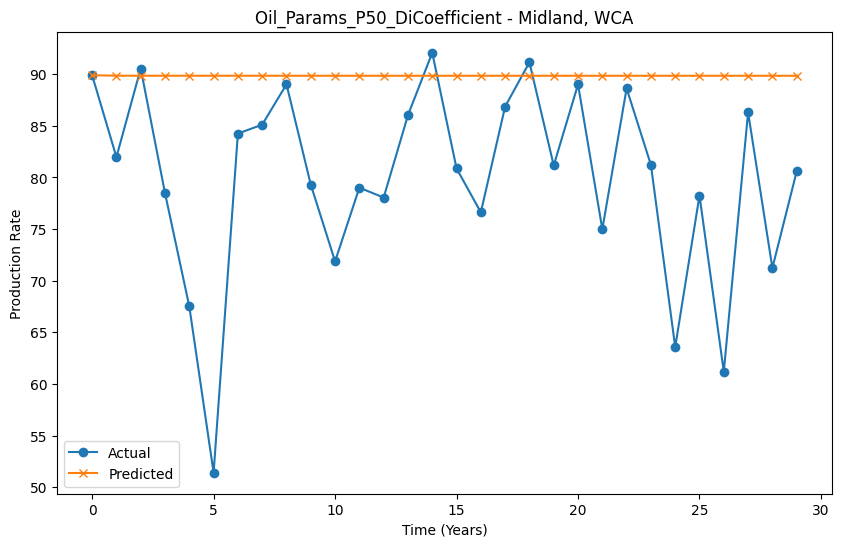

Oil_Params_P50_BCoefficient - Actual range: 0.6 to 1.4, Predicted range: -2582.10400390625 to 1258.81201171875


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_26052\943712837.py:34: RuntimeWarning: invalid value encountered in power
  q_t = q_i / (1 + b * D_i * time) ** (1 / b)


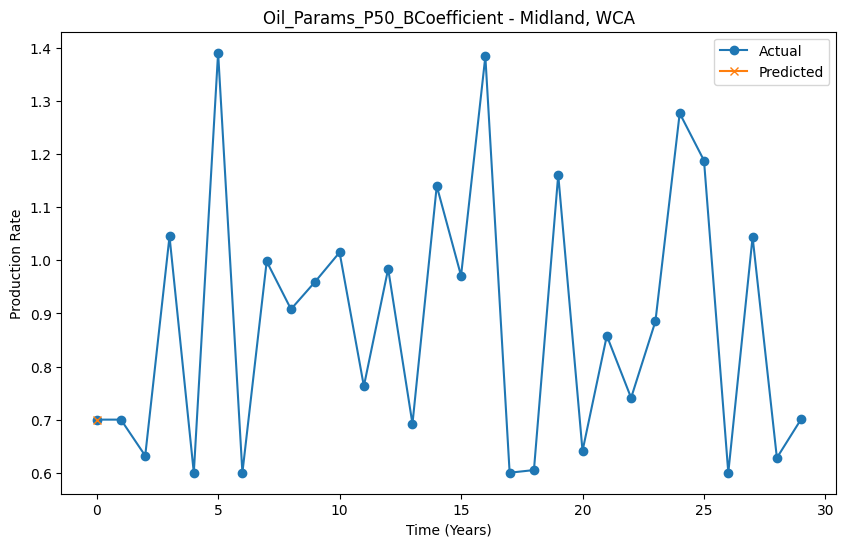

In [39]:
# Evaluate the models
evaluation_results = {}
for (basin, formation, config_str), model in models.items():
    # Filter the test data for the specific basin and formation
    combo_test = filter_by_basin_and_formation(test_df, basin, formation)
    # Extract numerical and categorical data from the filtered test set
    numerical_data = combo_test[numerical_columns].values
    categorical_data = [combo_test[col].astype(int).values.reshape(-1, 1) for col in categorical_columns]
    # Prepare the target values (y_true)
    y_true = combo_test[y_headers].values  # Use entire y_headers as output

    # Predict outputs using the model
    #print(f"Shapes before prediction: Numerical Data {numerical_data.shape}, Categorical Data {[c.shape for c in categorical_data]}")
    y_pred = model.predict([numerical_data] + categorical_data)
    #print(f"Predicted output shape: {y_pred.shape}")  # Debug the shape of predicted outputs

    # Calculating evaluation metrics
    if y_true.shape == y_pred.shape:
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        evaluation_results[(basin, formation, config_str)] = {'MSE': mse, 'MAE': mae}
        print(f"Performance for Basin: {basin}, Formation: {formation}, Config: {config_str} - MSE: {mse:.4f}, MAE: {mae:.4f}")
    else:
        print(f"Shape mismatch between y_true {y_true.shape} and y_pred {y_pred.shape}")

# Example usage for a specific configuration
basin = 'Midland'
formation = 'WCA'
config_str = str(configurations[0])
model = models[(basin, formation, config_str)]
evaluate_and_plot_hyperbolic_curve(basin, formation, model, numerical_columns, categorical_columns, y_headers)
